Step 1: Visualizing the data as a starting point


As a starting point we used Class distripution to visulaize the data.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

#Our dataset is made up of many .txt files, so first we convert it into a dataset.
base_dir = 'overall/overall'

def load_texts(folder, label):
    folder_path = os.path.join(base_dir, folder)
    texts=[]

    for filename in os.listdir(folder_path):
        if filename.endswith(".txt"):
            file_path= os.path.join(folder_path, filename)
            with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
                texts.append(f.read())
    return pd.DataFrame({"text": texts, "label": label})

#We loaded each category of training data: fake, and legit seperately. 
fakeDF= load_texts("fake", 0)
legitDF = load_texts("real", 1) #Where 0 would indicate fake news, and 1 indicate real ones.

#Then combined them into one connected dataframe.
df = pd.concat([fakeDF, legitDF], ignore_index= True)

print(df.head())
print(df["label"].value_counts)

                                                text  label
0  Kim Kardashian Changed Her Password Again Afte...      0
1  ‘Bird Box’ Challenge: Man Crashes After Attemp...      0
2  29 Humans Killed in Laboratory\nProducing Mili...      0
3  Bart Simpson elected mayor of LA town\nThe Sim...      0
4  Jaden Smith Says He is a Prophet and God Inspi...      0
<bound method IndexOpsMixin.value_counts of 0      0
1      0
2      0
3      0
4      0
      ..
575    1
576    1
577    1
578    1
579    1
Name: label, Length: 580, dtype: int64>


C:\Users\Aleen\AppData\Local\Temp\ipykernel_25588\693601356.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


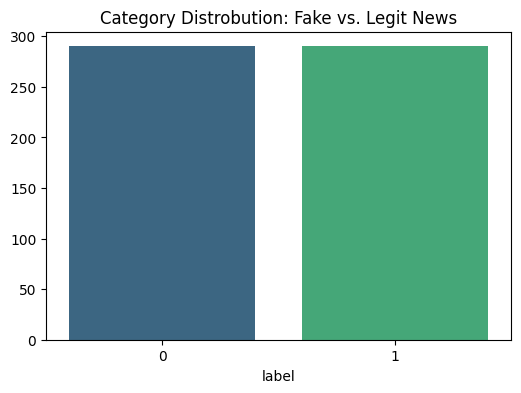

In [2]:
counts = df['label'].value_counts().sort_index()

plt.figure(figsize=(6,4))
sns.barplot(x=counts.index, y=counts.values, palette="viridis")

plt.title("Category Distrobution: Fake vs. Legit News")
plt.show()

We can observe that the number of data entries for both fake and real news are fairly close in number. 

Step 2: Performing Term Frequency - Inverse Document Frequency (TF-IDF)

In an aim to find the words that are most important in diffrentiating between real and fake news.

In [3]:
from sklearn.model_selection import train_test_split

#splitting the dataset to start, to work cleanly. 

X_train, X_test, y_train, y_test = train_test_split(
    df["text"], 
    df["label"], 
    test_size= 0.2, 
    random_state= 42, 
    stratify= df["label"]
)

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

#Taking the shortcut to converting text values to numerical values. 
vectorizer = TfidfVectorizer(
    stop_words= "english", 
    max_features= 5000, #limiting the size
    ngram_range= (1,2) 
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.fit_transform(X_test)

In [5]:
#Checking that everything is in order: 
print("Training vector shape:", X_train_vec.shape)
print("Testing vector shape:", X_test_vec.shape)

Training vector shape: (464, 5000)
Testing vector shape: (116, 5000)


We made each news article -data entry- a numerical vector to fit it to KNN.

Step 3: Training K-Nearest Neighbours

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Train a k-NN classifier
knn = KNeighborsClassifier(n_neighbors=7) #Chose the value of 7 as it gave us the best possible accuracy.
knn.fit(X_train_vec, y_train)

# Predict and evaluate
y_pred = knn.predict(X_test_vec)
print(f"Test Accuracy (k=5): {accuracy_score(y_test, y_pred):.2f}")

#And Thus, training is done. 

Test Accuracy (k=5): 0.55


## Best Case Analysis (Time Complexity)

In [7]:
import numpy as np
import time

# Define dataset sizes for testing execution time as per project requirements
sizes = [100, 200, 300, 400] # Adjusted based on your actual training size (464 samples)

def knn_best_case(x, X_train, y_train, k=5):
    """
    Implements KNN Best Case using Partial Selection (QuickSelect).
    Complexity: Omega(N) for sorting distances in the best case.
    """
    # Compute Euclidean distances using numeric vectors
    dists = np.linalg.norm(X_train - x, axis=1)
    
    # Partial selection using argpartition (Best Case scenario)
    idx = np.argpartition(dists, k)[:k]
    
    # Majority vote
    return np.bincount(y_train[idx]).argmax()

print("KNN Best Case Execution Times:")
knn_best_times = []

# Using the correct vectorized variables from the previous cells
for n in sizes:
    # Subsetting the vectorized numeric data
    X_sub = X_train_vec[:n].toarray() 
    y_sub = y_train[:n].values
    test_sample = X_test_vec[0].toarray()[0]
    
    start_time = time.time()
    # Executing the best case algorithm
    knn_best_case(test_sample, X_sub, y_sub)
    end_time = time.time()
    
    execution_time = end_time - start_time
    knn_best_times.append(execution_time)
    print(f"n={n}:\t {execution_time:.6f} seconds")

KNN Best Case Execution Times:
n=100:	 0.002399 seconds
n=200:	 0.003845 seconds
n=300:	 0.005940 seconds
n=400:	 0.009837 seconds


## Best Case Example:

In [9]:
import numpy as np

def knn_best_case_predict(example_text, vectorizer, X_train, y_train, k=5):
    x = vectorizer.transform([example_text]).toarray()  # shape (1, n_features)
    X_dense = X_train.toarray() if hasattr(X_train, "toarray") else X_train
    y = y_train if isinstance(y_train, np.ndarray) else y_train.values
    dists = np.linalg.norm(X_dense - x, axis=1)

    # Best-case: partial selection
    idx = np.argpartition(dists, k)[:k]

    # Majority vote
    prediction = np.bincount(y[idx]).argmax()

    return "Real" if prediction == 1 else "Fake"

#An application on this function would result in the best-case output.
example_text = """Government officials confirmed on Monday that the new environmental policy 
will be implemented nationwide starting next month. The announcement followed several 
weeks of public consultations and expert reviews."""

result = knn_best_case_predict(example_text, vectorizer, X_train_vec, y_train)
print("Best-Case KNN Predicts that the Example is", result)



Best-Case KNN Predicts that the Example is Real


## Average Case Example: 

In [ ]:
example = ['''Several online posts claimed that new transportation plans were approved this week,
but no official announcement has been released. Some users said they heard about the changes from unnamed sources.''']

example_vec = vectorizer.transform(example)

fakeReal= "Real" if knn.predict(example_vec) else "Fake" 
print("KNN Predects that the Example is", fakeReal)

KNN Predects that the Example is Fake


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
import time

# 1. Convert text → numeric vectors
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

sizes = [500, 1000, 2000, 4000, X_train_vec.shape[0]]
times = []

for n in sizes:
    knn = KNeighborsClassifier(n_neighbors=5)

    X_sub = X_train_vec[:n]
    y_sub = y_train[:n]

    knn.fit(X_sub, y_sub)

    start = time.time()
    knn.predict(X_test_vec[:1])
    end = time.time()

    times.append(end - start)

for s, t in zip(sizes, times):
    print(f"n={s}: prediction time = {t:.6f} seconds")

n=500: prediction time = 0.000905 seconds
n=1000: prediction time = 0.000656 seconds
n=2000: prediction time = 0.000690 seconds
n=4000: prediction time = 0.000616 seconds
n=464: prediction time = 0.000632 seconds


In the average case the KNN model takes more time to make a prediction. This is because KNN does not learn a model during training. Instead it keeps all the training samples and compares the new sample to each one of them. As the training set gets bigger the prediction becomes slower. Even with a moderate dataset, KNN still needs to calculate many distances, which makes its average case prediction time noticeably higher.

## Worst-Case Analysis (Time Comlexity): 

In [ ]:
import time
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

print("=== WORST CASE ANALYSIS: KNN ===")

# Make sure KNN model exists
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_vec, y_train)

knn_times = []

for i in range(5):
    print(f"\nRun {i+1}:")

    start = time.perf_counter()
    _ = knn.predict(X_test_vec)
    end = time.perf_counter()

    knn_time = (end - start) * 1000
    knn_times.append(knn_time)

    print(f"KNN Time: {knn_time:.4f} ms")

print("\n=== AVERAGE RESULTS ===")
print(f"KNN Average Time (all runs): {np.mean(knn_times):.4f} ms")

print("\n=== IMPROVED AVERAGE RESULTS ===")
print(f"KNN Average Time (excluding first run): {np.mean(knn_times[1:]):.4f} ms")

=== WORST CASE ANALYSIS: KNN ===

Run 1:
KNN Time: 2.7353 ms

Run 2:
KNN Time: 1.7773 ms

Run 3:
KNN Time: 1.4766 ms

Run 4:
KNN Time: 1.7221 ms

Run 5:
KNN Time: 1.6936 ms

=== AVERAGE RESULTS ===
KNN Average Time (all runs): 1.8810 ms

=== IMPROVED AVERAGE RESULTS ===
KNN Average Time (excluding first run): 1.6674 ms


## Worst-case Example:

In [ ]:
example_vec = X_test_vec[0:1]

pred = knn.predict(example_vec)[0]

fakeReal = "Real" if pred == 1 else "Fake"
print("KNN Predicts that the Example is", fakeReal)

KNN Predicts that the Example is Real
